# Portable EEG Headset RESTful API
**Built with:** FastAPI, `aiosqlite`, Python, `pytest`, `asyncio`, `httpx`

This project simulates a high-frequency (512Hz) data ingestion backend for telemedic devices. It features asynchronous CRUD operations, a SQLite database configured for concurrent writes (WAL mode), and full integration test coverage.

## System Architecture & High-Concurrency Optimization

To handle continuous 512Hz biological sensor data without data loss, the ingestion pipeline was optimized at both the network and database layers:

1. **Strict Data Validation (Pydantic & Enums):** Dropped malformed payloads instantly at the routing layer before they could consume database compute.
2. **Asynchronous Connection Pooling (`aiosqlite`):** Allowed the API to maintain a non-blocking event loop while waiting for disk I/O.
3. **Database Concurrency (SQLite WAL):** Transitioned from default lock-based writing to Write-Ahead Logging (`PRAGMA journal_mode=WAL`), allowing simultaneous read/write operations.
4. **Network Layer Throttling (`asyncio.Semaphore`):** Prevented OS-level TCP socket exhaustion by bounding concurrent inbound connections to pools of 50, stabilizing throughput.

In [5]:
import os

def print_directory_tree(startpath):
    print(f"📁 Project Directory: {os.path.abspath(startpath)}\n")
    for root, dirs, files in os.walk(startpath):
        # Skip hidden directories like .git or __pycache__
        dirs[:] = [d for d in dirs if not d.startswith('.') and d != '__pycache__']
        
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * level
        
        # Print the current folder
        if level > 0:
            print(f"{indent}📂 {os.path.basename(root)}/")
            
        subindent = ' ' * 4 * (level + 1)
        
        # Print the files within the folder
        for f in files:
            if not f.endswith('.pyc'):  # Ignore compiled python files
                print(f"{subindent}📄 {f}")

# Run the function on the current directory
print_directory_tree('.')

📁 Project Directory: c:\Users\mrpho\OneDrive\سطح المكتب\Year 3\Semester_1\Advanced Computer Programming\Projects_Advanced_Programming

    📄 ADLmain.py
    📄 advprog_test1.py
    📄 data_eeg.db
    📄 eeg_data.db
    📄 load_test.py
    📄 main.py
    📄 mainADL.py
    📄 mainNEC.py
    📄 mainTRY.py
    📄 main_p1.py
    📄 p1.py
    📄 practiceAdv.py
    📄 PrFinal.py
    📄 project_summary.ipynb
    📄 tempCodeRunnerFile.py
    📄 tempCodeRunnerFile.python
    📄 test_main.py


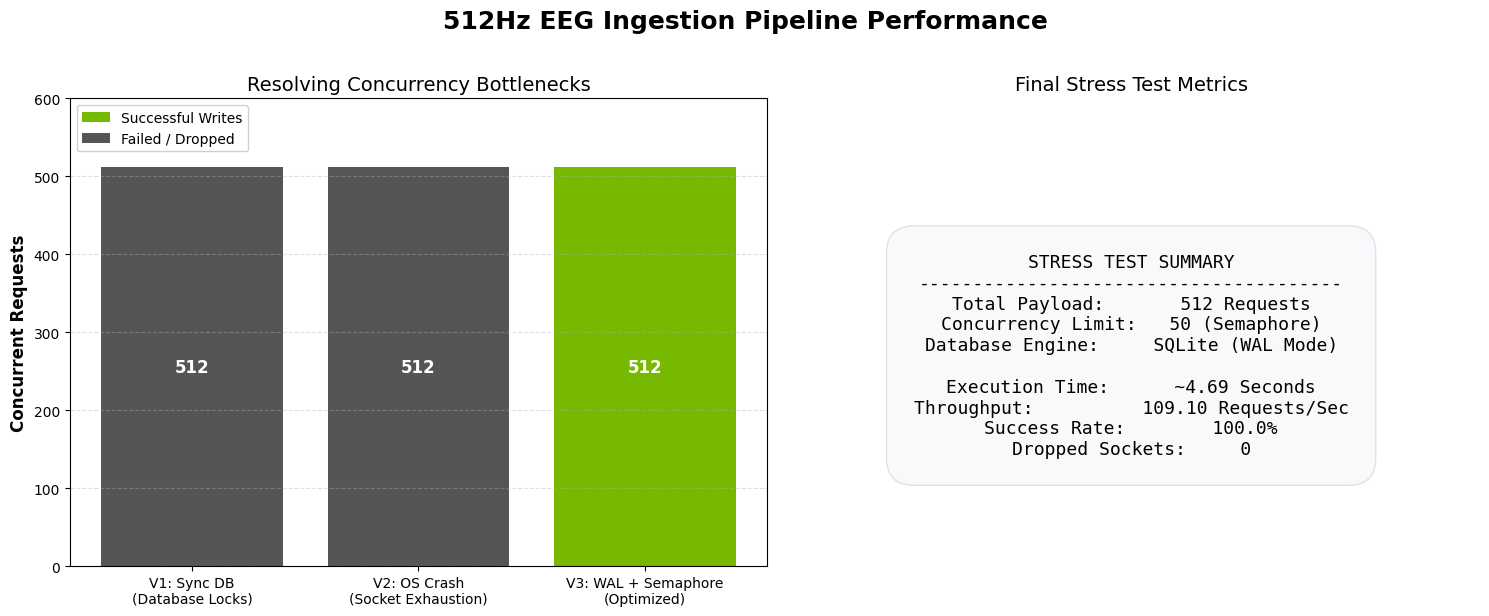

In [6]:
import matplotlib.pyplot as plt
import numpy as np

iterations = [
    'V1: Sync DB\n(Database Locks)', 
    'V2: OS Crash\n(Socket Exhaustion)', 
    'V3: WAL + Semaphore\n(Optimized)'
]
successes = [0, 0, 512]
failures = [512, 512, 0]

# Modern Color Palette
color_success = '#76b900'  # A vibrant tech green
color_fail = '#555555'     # A sleek slate grey

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('512Hz EEG Ingestion Pipeline Performance', fontsize=18, fontweight='bold', y=1.02)

# --- Chart 1: The Optimization Journey ---
bar_success = ax1.bar(iterations, successes, color=color_success, label='Successful Writes')
bar_fail = ax1.bar(iterations, failures, bottom=successes, color=color_fail, label='Failed / Dropped')

ax1.set_ylabel('Concurrent Requests', fontsize=12, fontweight='bold')
ax1.set_title('Resolving Concurrency Bottlenecks', fontsize=14)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Add headroom and data labels
ax1.set_ylim(0, 600)
ax1.bar_label(bar_success, label_type='center', color='white', fontweight='bold', fontsize=12)
ax1.bar_label(bar_fail, label_type='center', color='white', fontweight='bold', fontsize=12)

# Hide zero labels for a cleaner look
for text in ax1.texts:
    if text.get_text() == '0':
        text.set_alpha(0)

# --- Chart 2: Final Production Metrics ---
ax2.axis('off')
ax2.set_title('Final Stress Test Metrics', fontsize=14)

metrics_text = (
    "STRESS TEST SUMMARY\n"
    "---------------------------------------\n"
    "Total Payload:       512 Requests\n"
    "Concurrency Limit:   50 (Semaphore)\n"
    "Database Engine:     SQLite (WAL Mode)\n\n"
    "Execution Time:      ~4.69 Seconds\n"
    "Throughput:          109.10 Requests/Sec\n"
    "Success Rate:        100.0%\n"
    "Dropped Sockets:     0"
)

# Centered styling for the KPI box
ax2.text(0.5, 0.45, metrics_text, fontsize=13, family='monospace', 
         ha='center', va='center',
         bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1.5'))

plt.tight_layout()
plt.show()